In [10]:
import matplotlib.pyplot as plt
import re
import itertools


In [11]:
# Parse replicas
replicas = []
with open("replicas.log") as f:
    for line in f:
        parts = line.split()
        if parts[0] == "app":
            replicas.append(int(parts[6]))

# Parse vegeta 99th latency (in seconds)
latencies = []
files = ["vegeta.1.log", "vegeta.2.log", "vegeta.3.log"]
lines = itertools.chain.from_iterable(open(f) for f in files)
for line in lines:
    if line.strip().startswith("Latencies"):
        # format: [mean, 50, 95, 99, max]
        vals = re.findall(r'[\d.]+(?:ms|s|µs|ns)', line)
        p99 = vals[3]
        if p99.endswith("ms"):
            latencies.append(float(p99[:-2]) / 1000)
        elif p99.endswith("µs"):
            latencies.append(float(p99[:-2]) / 1e6)
        elif p99.endswith("ns"):
            latencies.append(float(p99[:-2]) / 1e9)
        else:
            latencies.append(float(p99[:-1]))
# plt.savefig("plot.png", dpi=150)
# print("Saved plot.png")


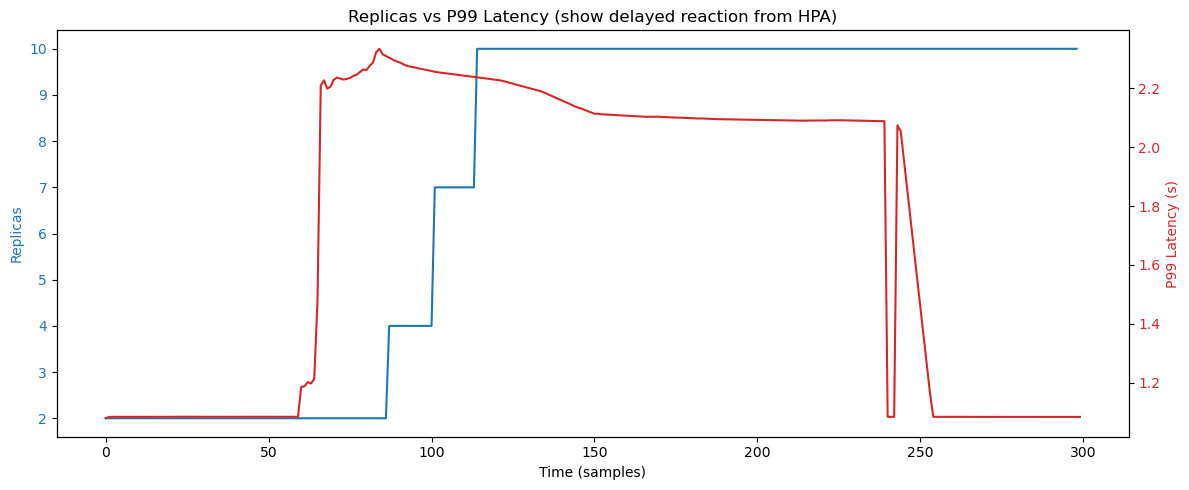

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel("Time (samples)")
ax1.set_ylabel("Replicas", color="tab:blue")
ax1.plot(replicas[:len(latencies)-1], color="tab:blue", label="Replicas")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("P99 Latency (s)", color="tab:red")
ax2.plot(latencies, color="tab:red", label="P99 Latency")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Replicas vs P99 Latency (show delayed reaction from HPA)")
fig.tight_layout()
fig.show()

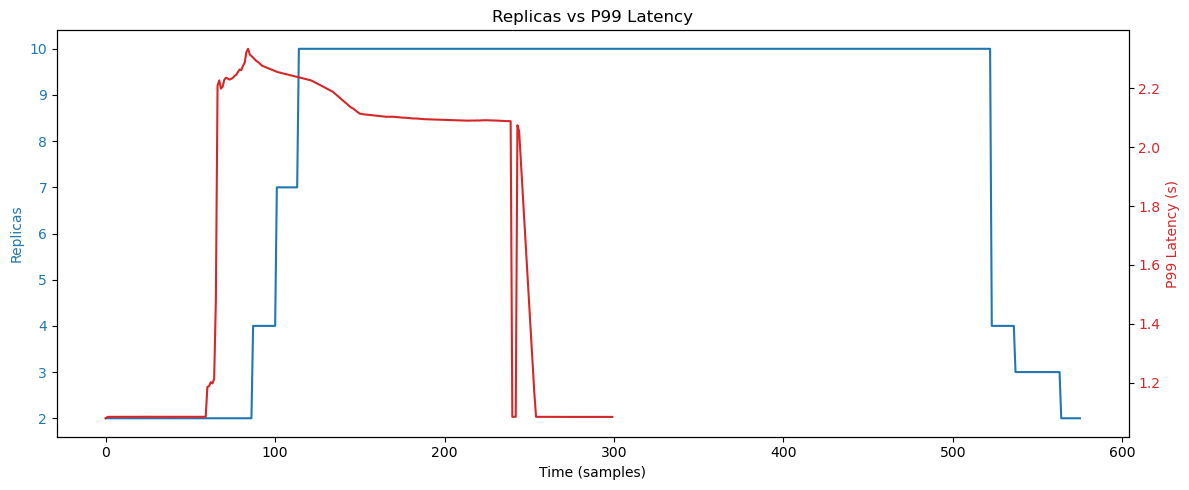

In [13]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel("Time (samples)")
ax1.set_ylabel("Replicas", color="tab:blue")
ax1.plot(replicas, color="tab:blue", label="Replicas")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("P99 Latency (s)", color="tab:red")
ax2.plot(latencies, color="tab:red", label="P99 Latency")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Replicas vs P99 Latency - Show time to drain node (over provisioning)")
fig.tight_layout()
fig.show()